In [1]:
from google.colab import files

uploaded = files.upload()

Saving Google.csv to Google.csv


In [2]:
import pandas as pd

df = pd.read_csv('Google.csv')

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659000
1,2004-08-20,50.555557,54.594593,50.300301,54.209209,54.209209,22834300
2,2004-08-23,55.430431,56.796795,54.579578,54.754753,54.754753,18256100
3,2004-08-24,55.675674,55.855854,51.836838,52.487488,52.487488,15247300
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188600


In [3]:
print(df.shape)

(4041, 7)


In [4]:
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [5]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659000
1,2004-08-20,50.555557,54.594593,50.300301,54.209209,54.209209,22834300
2,2004-08-23,55.430431,56.796795,54.579578,54.754753,54.754753,18256100
3,2004-08-24,55.675674,55.855854,51.836838,52.487488,52.487488,15247300
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188600


In [6]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
4036,2020-08-31,1643.569946,1644.500000,1625.329956,1629.530029,1629.530029,1321100
4037,2020-09-01,1632.160034,1659.219971,1629.530029,1655.079956,1655.079956,1133800
4038,2020-09-02,1668.010010,1726.099976,1660.189941,1717.390015,1717.390015,2476100
4039,2020-09-03,1699.520020,1700.000000,1607.709961,1629.510010,1629.510010,3180200
4040,2020-09-04,1609.000000,1634.989990,1537.970093,1581.209961,1581.209961,2792533


In [7]:
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [8]:
print(df.describe())

              Open         High          Low        Close    Adj Close  \
count  4041.000000  4041.000000  4041.000000  4041.000000  4041.000000   
mean    533.983149   538.995819   528.658860   533.999060   533.999060   
std     383.007917   386.590237   379.488087   383.326004   383.326004   
min      49.644646    50.920921    48.028027    50.055054    50.055054   
25%     241.211212   243.688690   238.873871   241.036041   241.036041   
50%     342.592590   345.795807   338.598602   342.177185   342.177185   
75%     791.979980   798.000000   786.200012   790.460022   790.460022   
max    1699.520020  1726.099976  1660.189941  1717.390015  1717.390015   

             Volume  
count  4.041000e+03  
mean   6.909802e+06  
std    7.895987e+06  
min    5.206000e+05  
25%    1.844600e+06  
50%    4.191600e+06  
75%    8.702600e+06  
max    8.215110e+07  


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

print("Fecha inicial:", df['Date'].min())
print("Fecha final:", df['Date'].max())

Fecha inicial: 2004-08-19 00:00:00
Fecha final: 2020-09-04 00:00:00


EVALUACION HISTORICA


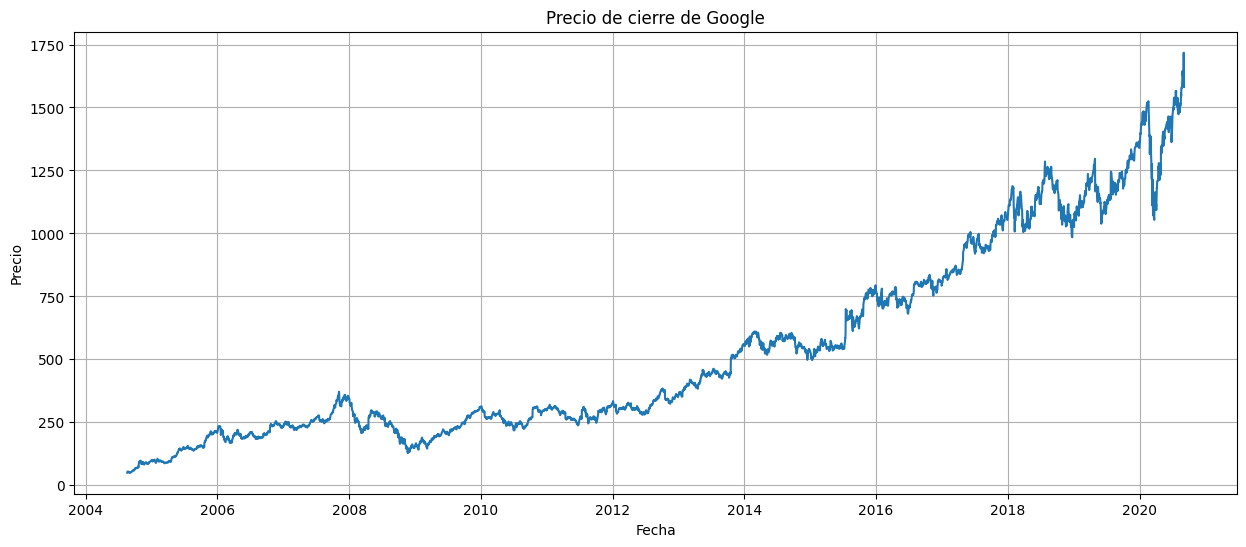

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(df['Date'], df['Close'])
plt.title('Precio de cierre de Google')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.grid()
plt.show()

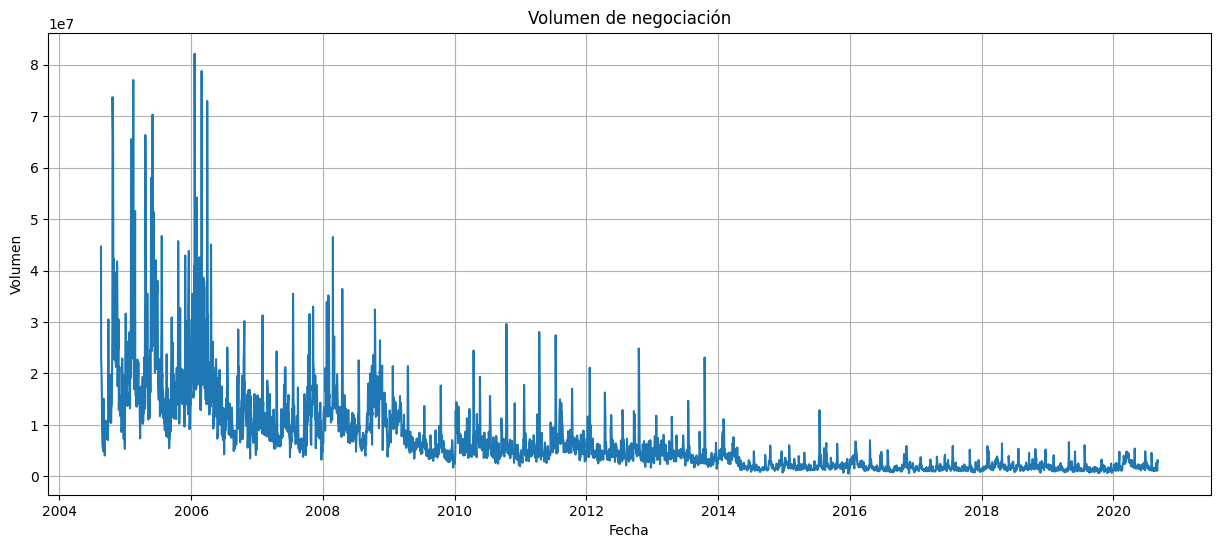

In [11]:
plt.figure(figsize=(15,6))
plt.plot(df['Date'], df['Volume'])
plt.title('Volumen de negociación')
plt.xlabel('Fecha')
plt.ylabel('Volumen')
plt.grid()
plt.show()

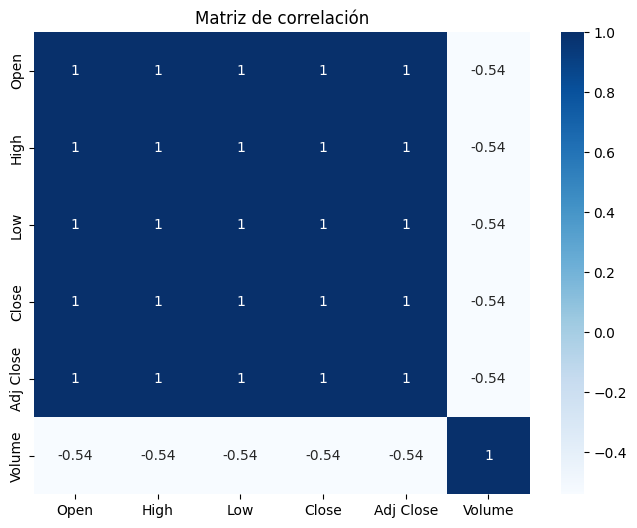

In [12]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Open','High','Low','Close','Adj Close','Volume']]
    .corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Matriz de correlación')
plt.show()

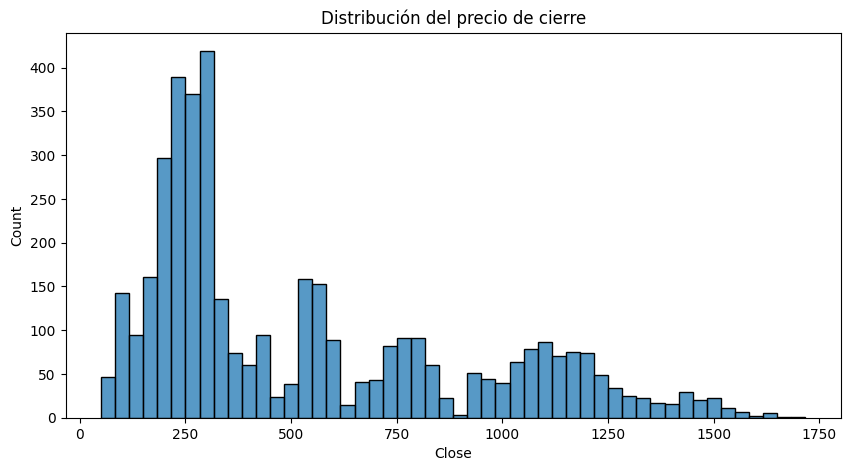

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(df['Close'], bins=50)

plt.title('Distribución del precio de cierre')
plt.show()

In [14]:
df['MA7'] = df['Close'].rolling(7).mean()

df['MA30'] = df['Close'].rolling(30).mean()

df['Return'] = df['Close'].pct_change()

In [15]:
df['Target'] = (
    df['Close'].shift(-1) > df['Close']
).astype(int)

In [16]:
df = df.dropna()

print(df.shape)

(4012, 11)


In [17]:
df['Target'].value_counts(normalize=True)*100

,proportion
Target,
1,52.168495
0,47.831505


FASE2: ENTRENAMIENTO DEL PRIMER MODELO

In [19]:
X = df[['Open','High','Low','Volume','MA7','MA30','Return']]

y = df['Target']

In [20]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [21]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
y_pred = modelo.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.49688667496886674
              precision    recall  f1-score   support

           0       0.47      0.72      0.57       374
           1       0.55      0.31      0.39       429

    accuracy                           0.50       803
   macro avg       0.51      0.51      0.48       803
weighted avg       0.52      0.50      0.48       803



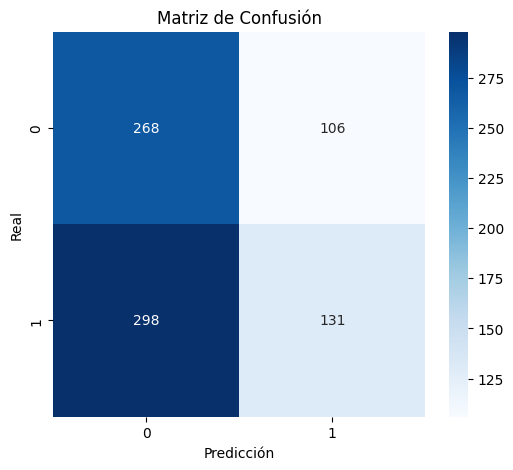

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.49688667496886674


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.72      0.57       374
           1       0.55      0.31      0.39       429

    accuracy                           0.50       803
   macro avg       0.51      0.51      0.48       803
weighted avg       0.52      0.50      0.48       803



In [27]:
!pip install xgboost

In [28]:
from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    random_state=42
)

modelo_xgb.fit(X_train, y_train)

y_pred_xgb = modelo_xgb.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.47571606475716066


In [30]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

print(
    accuracy_score(y_test, y_pred_lr)
)

0.5342465753424658


In [31]:
delta = df['Close'].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df['RSI'] = 100 - (100 / (1 + rs))

In [32]:
df['EMA20'] = df['Close'].ewm(span=20).mean()

In [33]:
df['EMA50'] = df['Close'].ewm(span=50).mean()

In [34]:
df['BB_Middle'] = df['Close'].rolling(20).mean()

std = df['Close'].rolling(20).std()

df['BB_Upper'] = df['BB_Middle'] + (2 * std)

df['BB_Lower'] = df['BB_Middle'] - (2 * std)

In [35]:
X = df[
    [
        'Open',
        'High',
        'Low',
        'Volume',
        'MA7',
        'MA30',
        'Return',
        'RSI',
        'EMA20',
        'EMA50'
    ]
]

In [36]:
df[['RSI','EMA20','EMA50']].head()

,RSI,EMA20,EMA50
29,NaN,64.864868,64.864868
30,NaN,65.647898,65.625526
31,NaN,66.363815,66.309348
32,NaN,67.198241,67.090326
33,NaN,67.539398,67.418752


In [37]:
df = df.dropna()

In [38]:
X = df[
    [
        'Open',
        'High',
        'Low',
        'Volume',
        'MA7',
        'MA30',
        'Return',
        'RSI',
        'EMA20',
        'EMA50'
    ]
]

y = df['Target']

In [39]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.5356695869837297


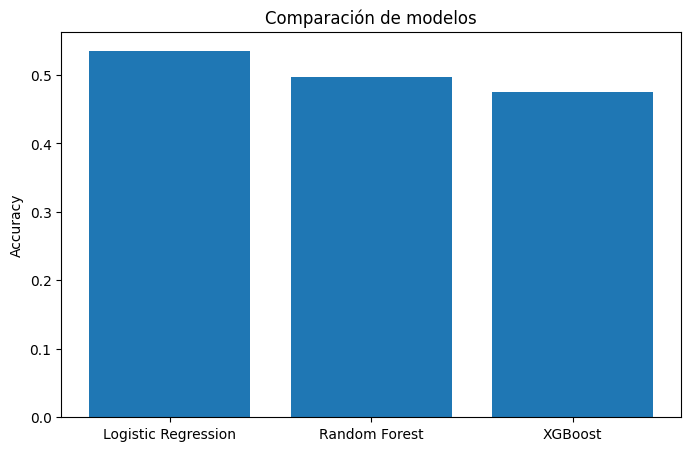

In [41]:
import matplotlib.pyplot as plt

modelos = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy = [0.5357, 0.4969, 0.4757]

plt.figure(figsize=(8,5))
plt.bar(modelos, accuracy)

plt.title('Comparación de modelos')
plt.ylabel('Accuracy')

plt.show()

In [42]:
import pickle

with open('modelo_lr.pkl', 'wb') as f:
    pickle.dump(modelo_lr, f)

In [43]:
import os

os.listdir()

['.config', 'Google.csv', 'modelo_lr.pkl', 'sample_data']

In [44]:
from google.colab import files

files.download('modelo_lr.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
files.download('Google.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>